In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import os
import numpy as np
from matplotlib import pyplot as plt
import camb
from camb import model, initialpower
from camb import sources

print('Using CAMB %s installed at %s' % (camb.__version__, os.path.dirname(camb.__file__)))
# make sure the version and path is what you expect



from scipy.interpolate import splrep, splev




Using CAMB 1.6.5 installed at /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/camb


In [2]:
#LensQuEst

from importlib import reload

import universe
reload(universe)
from universe import *

import halo_fit
reload(halo_fit)
from halo_fit import *

import weight
reload(weight)
from weight import *

import pn_2d
reload(pn_2d)
from pn_2d import *

import cmb
reload(cmb)
from cmb import *

import flat_map
reload(flat_map)
from flat_map import *


plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath} \usepackage{amssymb}' # plots will be using Latex; without it, LensQuest doesnt run

# MeerKat HI specifications functions + HI shot noise

In [3]:

#fiducial bHI fit, SKA Red Book
def bias_HI(zc):
    return 0.67+0.18*zc+0.05*zc**2

#mean brightness temperature [mK], SKA Red Book

def Tb(zc):
    return 0.0559+0.2324*zc-0.024*zc**2


#in MHz, K
nu, Tsys_eta, a_eff=np.loadtxt('UHF_Tsys.txt',unpack=True)

def Tsys_mk(zc):
    """Returns interpolated system temperature in mK
    """
    ratio=0.72
    T_sys_meerkat_rep=splrep(nu,Tsys_eta)
    T_sys_meerkat=splev(HI/(1+zc),T_sys_meerkat_rep)*1e3
    return T_sys_meerkat*ratio

def P_N_instr(zc,Dzbin,omega,tobs):
    ## T is mK and HI in MHz.
    Tsys=Tsys_mk(zc)*10
    Dnu=HI*(1/(zc-Dzbin/2)-1/(zc+Dzbin/2))*1e6
    clinstr=Tsys**2*omega/(2*Ndishes*tobs*3600*Dnu)
    return clinstr

## Beam

def beam_no_ell(theta_fwhm):
    ## theta_fwhm in rad
    return np.exp(-theta_fwhm**2/16/np.log(2))

def theta_fwhm(lamb,D):
    ## lamb in m
    ## D in m
    return 1.22*lamb/D

def lamb(nu):
    ## nu in Hz
    return c_light*1e3/nu

def nu_obs(z):
    return HI/(1+z)

def theta(zc,D):
    lamb_obs=lamb(nu_obs(zc)*1e6)
    return theta_fwhm(lamb_obs,D)

def beam_l(beam_mk,l):
    return (beam_mk)**(l*(l+1))


### fixed parameters
Ndishes=60
Ddish=13.5
Sa=10000
f_sky = Sa /  41253.0
Omega_surv=Sa*(np.pi/180)**2
t10k=1300
tobs=t10k*Sa/10000

zc=0.61
HI=1420.4 #in MHz
c_light=3e8



#REDSHIFT DEFINITION
zs = np.array([0.43,0.61,0.8,1.0,1.25])
Delta_zs = np.array([0.06,0.18,0.19,0.2,0.25])
sigma_zs = Delta_zs/2




#tobs=180
PN_HI = P_N_instr(zs,Delta_zs,Omega_surv,tobs)

theta_fwhm_mk=theta(zs,Ddish)

beam_mk=beam_no_ell(theta_fwhm_mk)


#theta_fwhm_mk

In [4]:

#zs=np.array([0.43,0.61,0.8,1.0,1.25])
#Delta_z=np.array([0.06,0.18,0.2,0.2,0.3])
#faz o SNR para cada um e o SNR total de todos combinados
#zs=np.array([0.61,0.8,1.0])
#Delta_z=np.array([0.18,0.2,0.2])
#SNR de um único bin

zs1=np.array([0.81])
Delta_zs1=np.array([0.58])

# CAMB functions for $C_l$

In [5]:
def CAMB_Cl(Z, Delta_Z, lmin, lmax):
    """""
    Outputs: [0] = Lensing Auto (independent of z) ; [1] = 
    """""
    
    M_pars = camb.CAMBparams()
    M_pars.set_cosmology(H0=67.8, ombh2=0.0222, omch2=0.119, mnu=0.06, omk=0, tau=0.0952)  #flat ACDM-nu cosmology
    M_pars.InitPower.set_params(As=2.21e-9, ns=0.961)
    
    #MeerKat galaxy (?) sample
    zi = Z
    b = bias_HI(zi)
    
    M_pars.SourceWindows = [
        sources.GaussianSourceWindow(source_type='counts', bias=b, redshift=zi, sigma=Delta_Z/2)
    ]
    
    #we want CMB lensing
    M_pars.Want_CMB_lensing = True
    M_pars.set_for_lmax(lmax, lens_potential_accuracy=1)
    
    #results
    results = camb.get_results(M_pars)
    
    # extract spectra disctionary (window x power ...)
    # raw_cl=True ensures we get the pure spectra without any L(L+1)/2pi scaling applied by default
    cls = results.get_source_cls_dict(raw_cl=True)
    
    #array for the multipoles (ell)
    #l_max = lmax
    ls = np.linspace(lmin, lmax, lmax+1)
    
    
    #HI-HI auto-spectrum (Window 1 x Window 1)
    cl_hi_hi = cls['W1xW1'][:lmax+1]
    #HIHI noise
    
    
    #"os cls do HI têm de ser multiplicados pela temperatura"
    cl_hi_hi *= Tb(zi)**2
    
    # Galaxy - Lensing Potential cross-spectrum 
    cl_hi_phi = cls['W1xP'][:lmax+1]
    
    # Lensing Potential to Lensing Convergence (kappa)
    #  multiply by l(l+1)/2 to get the galaxy-convergence cross-spectrum
    scaling_factor = (ls * (ls + 1)) / 2.0
    cl_k_hi = scaling_factor * cl_hi_phi * Tb(zi)
    
    # Lensing Potential auto-spectrum (PxP)
    cl_phi_phi = cls['PxP'][:lmax+1]
    
    # potential to Convergence auto-spectrum (kappa-kappa)
    cl_k_k = (scaling_factor**2) * cl_phi_phi
        
    return (cl_k_k, cl_hi_hi, cl_k_hi)



# Noises function and SNR

In [6]:
#Lensing noise, 0th order (expression seems to be wrong, only valid for ?)

def Nlk0(lmin, lmax):

    ls = np.linspace(lmin, lmax, int(lmax)+1 )
    
    Tcmb=2.725e6 #micro K
    theta_rad = np.radians(1/3) #from Bacon 2024

    tpix= 3# 10.5 * 3600 #10.5 hours in Bacon 2024 time observed
    tpix2=3.1536e7 #1 year
    
    theta_fwhm = theta_rad
    sigma_b = theta_fwhm * 1 /( (8*np.log(2)**0.5) )
    s = 0.65 # microK s**0.5 (sensitivity)

    w_inv = 1e-6#4*np.pi * (s/Tcmb)**2 * 1/(tpix*Npix)  #variance per unit area, inversed
    #print(w_inv)
    #print((s/Tcmb)**2 )
    
    return f_sky * w_inv * np.exp((ls**2) * (sigma_b**2))

In [7]:
# Cross Power Spectrum Sigma

def cross_sigma(Z,Delta_Z, lmin, lmax):
    ls = np.linspace(lmin, lmax, int(lmax)+1 )
    
    N_hihi = P_N_instr(Z,Delta_Z,Omega_surv,tobs)
    N_kk = Nlk0(lmin, lmax)
    
    cl_k_k, cl_hihi, cl_k_hi = CAMB_Cl(Z, Delta_Z, lmin, lmax)
    
    #Theoretical noise of cross power per multipole l - Giannantonio 2015
    sigma_C_k_hi = np.zeros_like(ls, dtype=float)
    for l, L in enumerate(ls):
        #print(l, N_kk)
        variance = (cl_k_hi[l]**2) + (cl_k_k[l] + N_kk[l]) * (cl_hihi[l] + N_hihi)
        sigma_C_k_hi[l] = np.sqrt(variance / (f_sky * (2 * L + 1)))

    return(sigma_C_k_hi)


def noises_l(Z, Delta_Z, lmin, lmax):

    ls = np.linspace(lmin, lmax, int(lmax)+1 )
    ### fixed parameters
    Ndishes=60
    Ddish=13.5
    Sa=10000
    f_sky = Sa /  41253.0
    omega=Sa*(np.pi/180)**2
    t10k=1300
    tobs=t10k*Sa/10000

    #Nl_k_k = LensQuEst_noise()
    Nl_k_k = Nlk0(lmin, lmax)
    Nl_hi_hi = np.zeros(len(ls))+P_N_instr(Z,Delta_Z, omega,tobs)
    Nl_k_hi = cross_sigma(Z, Delta_Z, lmin, lmax) 

    return (Nl_k_k, Nl_hi_hi, Nl_k_hi)

In [8]:
def SN(Z, DeltaZ, lmin, lmax):
    
    ls = np.linspace(lmin, lmax, lmax+1 )
    cl_k_k, cl_hihi, cl_k_hi = CAMB_Cl(Z, DeltaZ, lmin, lmax)
    N_kk, N_hihi, N_k_hi = noises_l(Z, DeltaZ, lmin, lmax)
    
    
    cumulative_snr = np.zeros_like(ls, dtype=float)
    snr_squared_sum = 0.0
    
    snr_l_sq = f_sky*(2*ls+1)*(cl_k_hi**2) / ( (cl_k_hi**2) + (cl_k_k + N_kk) * (cl_hihi + N_hihi) )
    
    cumulative_snr = np.sqrt(np.cumsum(snr_l_sq))
    
    snr_l_sq_th = (2*ls+1)*(cl_k_hi**2) / ((cl_k_hi**2) + (cl_k_k) * (cl_hihi))
    cumulative_snr_th = np.sqrt(np.cumsum(snr_l_sq_th[2:]))
    
    return (cumulative_snr,cumulative_snr_th)


c_snr = SN(0.61,0.18, 20, 2000)


/var/folders/_n/vm9nc6_54_1_2m60q4p1xhww0000gn/T/ipykernel_16003/1800645007.py:15: RuntimeWarning: invalid value encountered in divide
  snr_l_sq_th = (2*ls+1)*(cl_k_hi**2) / ((cl_k_hi**2) + (cl_k_k) * (cl_hihi))


# LensQuEst

In [9]:
def lensquest(lmin, lmax):
    
    #Map properties
    # number of pixels for the flat map
    nX = 1200#400 #1200
    nY = 1200#400 #1200
    
    # map dimensions in degrees
    sizeX = 10.
    sizeY = 10.
        
    # basic map object
    baseMap = FlatMap(nX=nX, nY=nY, sizeX=sizeX*np.pi/180., sizeY=sizeY*np.pi/180.)
    # multipoles to include in the lensing reconstruction
    lMin = lmin  #from ~35 before Noise will get infinite in the beggining
    lMax = lmax
    
    # ell bins for power spectra
    nBins = 20  # number of bins
    #lRange = (1., 2*lMax)  # range for power spectra
    
    # Adjust the lMin and lMax to the assumptions of the analysis
    # CMB S3 specs
    cmb = StageIVCMB(beam=1., noise=1., lMin=lMin, lMaxT=lMax, lMaxP=lMax, atm=False)
    cmb2 = StageIVCMB(beam=1., noise=1., lMin=lMin, lMaxT=lMax, lMaxP=lMax, atm=False)
    
    # Total power spectrum, for the lens reconstruction
    forCtotal = lambda l: cmb.flensedTT(l) + cmb.fdetectorNoise(l)
    
    # reinterpolate: gain factor 10 in speed
    #L = np.logspace(np.log10(lMin), np.log10(lMax), lMax+1)  #switch to this and everything else like F needs to switch too tho
    l = np.linspace(lMin,lMax,lMax+1)
    
    Fl = np.array(list(map(forCtotal, l)))
    #F = np.array(list(map(forCtotal, L)))
    
    #cmb.fCtotal = interp1d(L, F, kind='linear', bounds_error=False, fill_value=0.)
    cmb2.fCtotal = interp1d(l, Fl, kind='linear', bounds_error=False, fill_value=0.)
    
    #CMB lensing power spectrum
    u = UnivPlanck15()
    #u = UnivMeerKlass()
    halofit = Halofit(u, save=False)
    w_cmblens = WeightLensSingle(u, z_source=1100., name="cmblens")
    p2d_cmblens = P2dAuto(u, halofit, w_cmblens, save=False) #here
    
    #standard quadratic estimator
    #fNqCmb_fft = baseMap.forecastN0Kappa(cmb.funlensedTT, cmb.fCtotal, lMin=lMin, lMax=lMax, test=False)
    fNqCmb_fft2 = baseMap.forecastN0Kappa(cmb2.funlensedTT, cmb2.fCtotal, lMin=lMin, lMax=lMax, test=False)
    
    #Nq = fNqCmb_fft(L)
    Nq2 = fNqCmb_fft2(l)
    #print(Nq, Nq2)
    Clq2 = p2d_cmblens.fPinterp(l)

    return Clq2, Nq2


In [10]:
Sa=10000
f_sky = Sa /  41253.0
def SNq(Z, DeltaZ, lmin, lmax):  #with Lensquest Noise
    
    ls = np.linspace(lmin, lmax, lmax+1 )
    cl_k_k, cl_hihi, cl_k_hi = CAMB_Cl(Z, DeltaZ, lmin, lmax)
    N_kk, N_hihi, N_k_hi = noises_l(Z, DeltaZ, lmin, lmax)
    
    #cross sigma with quest noise
    #ls = np.linspace(lmin, lmax, lmax+1 )
    Clkq, Nkq = lensquest(lmin, lmax)
    sigma_C_k_hiq = np.zeros_like(ls, dtype=float)
    #Nkq[np.isinf(Nkq)] = 0
    #print(Clkq, Nkq)
    for l, L in enumerate(ls):
        variance = (cl_k_hi[l]**2) + (Clkq[l] + Nkq[l]) * (cl_hihi[l] + N_hihi[l])
        #print(variance, Clkq, Nkq)
        sigma_C_k_hiq[l] = np.sqrt(variance / (f_sky * (2 * L + 1)))

    
    #now onto snr
    cumulative_snr = np.zeros_like(ls, dtype=float)
    
    snr_l_sq = f_sky*(2*ls+1)*(cl_k_hi**2) / ( (cl_k_hi**2) + (Clkq + Nkq) * (cl_hihi + N_hihi) )
    
    cumulative_snr = np.sqrt(np.cumsum(snr_l_sq))
    
    #snr_l_sq_th = (2*ls+1)*(cl_k_hi**2) / ((cl_k_hi**2) + (cl_k_k) * (cl_hihi))
    #cumulative_snr_th = np.sqrt(np.cumsum(snr_l_sq_th[2:]))
    
    return (cumulative_snr, sigma_C_k_hiq)

/var/folders/_n/vm9nc6_54_1_2m60q4p1xhww0000gn/T/ipykernel_16003/1800645007.py:15: RuntimeWarning: invalid value encountered in divide
  snr_l_sq_th = (2*ls+1)*(cl_k_hi**2) / ((cl_k_hi**2) + (cl_k_k) * (cl_hihi))


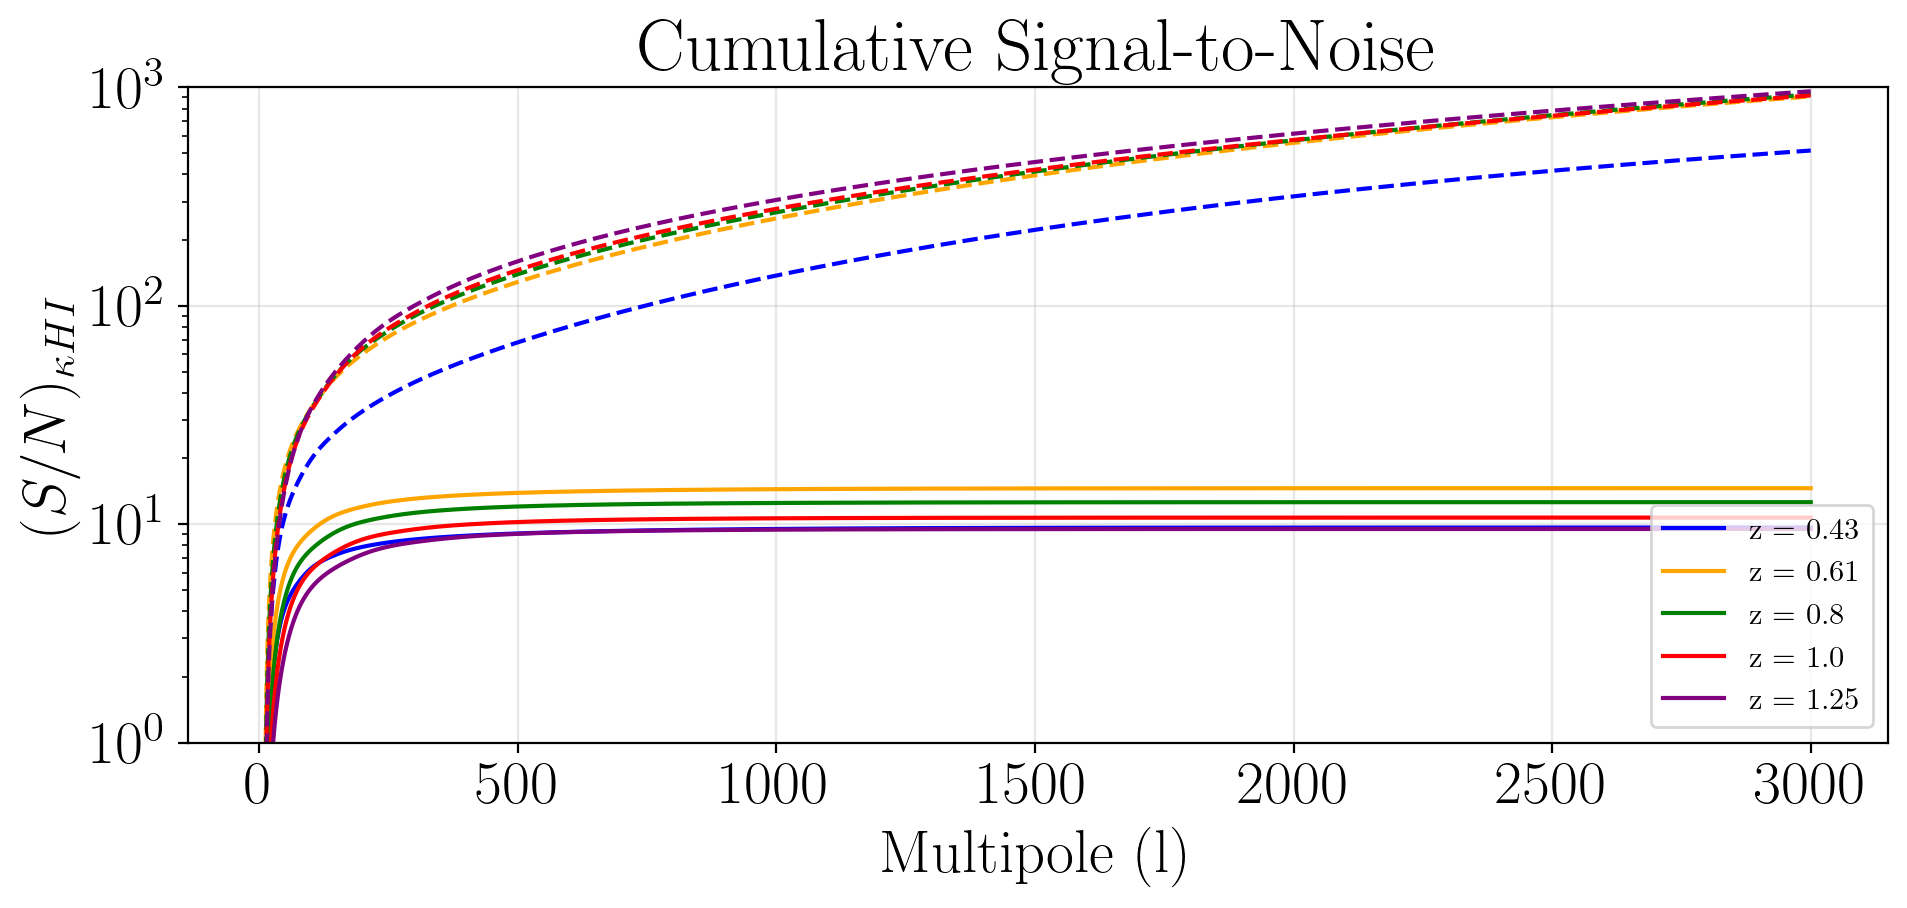

In [11]:
fig, (ax3) = plt.subplots(1, 1, figsize=(10, 5), sharex=True)
ax3.set_yscale('log')
ax3.set_ylabel(r'$(S/N)_{\kappa HI}$')
ax3.set_xlabel('Multipole (l)')
ax3.set_title('Cumulative Signal-to-Noise')
#ax3.set_xlim(0, 2000)
ax3.set_ylim(1, 1000)

l_min=10
l_max=3000
ls=np.linspace(l_min,l_max,l_max+1 )

colors=['blue','orange','green', 'red', 'purple']
for i, Zi in enumerate (zs):
    c_snr, c_snr_th = SN(Zi, Delta_zs[i],l_min, l_max)
     
    ax3.plot(ls[2:], c_snr[2:], label='z = {}'.format(Zi), color=colors[i] )
    ax3.plot(ls[2:], c_snr_th, color=colors[i], linestyle='--')



ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=11, loc='lower right')
plt.tight_layout()

/Users/l_luciano__/Desktop/J/CMBxHI Meerkat/cmb.py:32: RuntimeWarning: divide by zero encountered in scalar divide
  self.fdl_to_cl = lambda l: 1./( l*(l+1.)/(2.*np.pi) )
/Users/l_luciano__/Desktop/J/CMBxHI Meerkat/cmb.py:74: RuntimeWarning: invalid value encountered in scalar multiply
  self.flensedTT = lambda l: (l>=lmin_lensedCMB and l<=lmax_lensedCMB) * self.flensedTT_template(l) * self.fdl_to_cl(l)
/Users/l_luciano__/Desktop/J/CMBxHI Meerkat/cmb.py:42: RuntimeWarning: invalid value encountered in scalar multiply
  self.funlensedTT = lambda l: (l>=lmin_unlensedCMB and l<=lmax_unlensedCMB) * self.funlensedTT_template(l) * self.fdl_to_cl(l)


computing the reconstruction noise
Doing full calculation: computeQuadEstPhiNormalizationFFT


/Users/l_luciano__/Desktop/J/CMBxHI Meerkat/flat_map.py:1655: RuntimeWarning: divide by zero encountered in divide
  resultFourier = 1./resultFourier
/Users/l_luciano__/Desktop/J/CMBxHI Meerkat/flat_map.py:1655: RuntimeWarning: invalid value encountered in divide
  resultFourier = 1./resultFourier
/Users/l_luciano__/Desktop/J/CMBxHI Meerkat/flat_map.py:1715: RuntimeWarning: divide by zero encountered in log
  f = lambda l: np.exp(lnfln(np.log(l)))
/var/folders/_n/vm9nc6_54_1_2m60q4p1xhww0000gn/T/ipykernel_16003/388292195.py:19: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(ls[2:], cambcl[2:], 'k-', linestyle='--', lw=3, label=r'signal CAMB')


Text(0, 0.5, '$C_l^{\\kappa \\kappa}$')

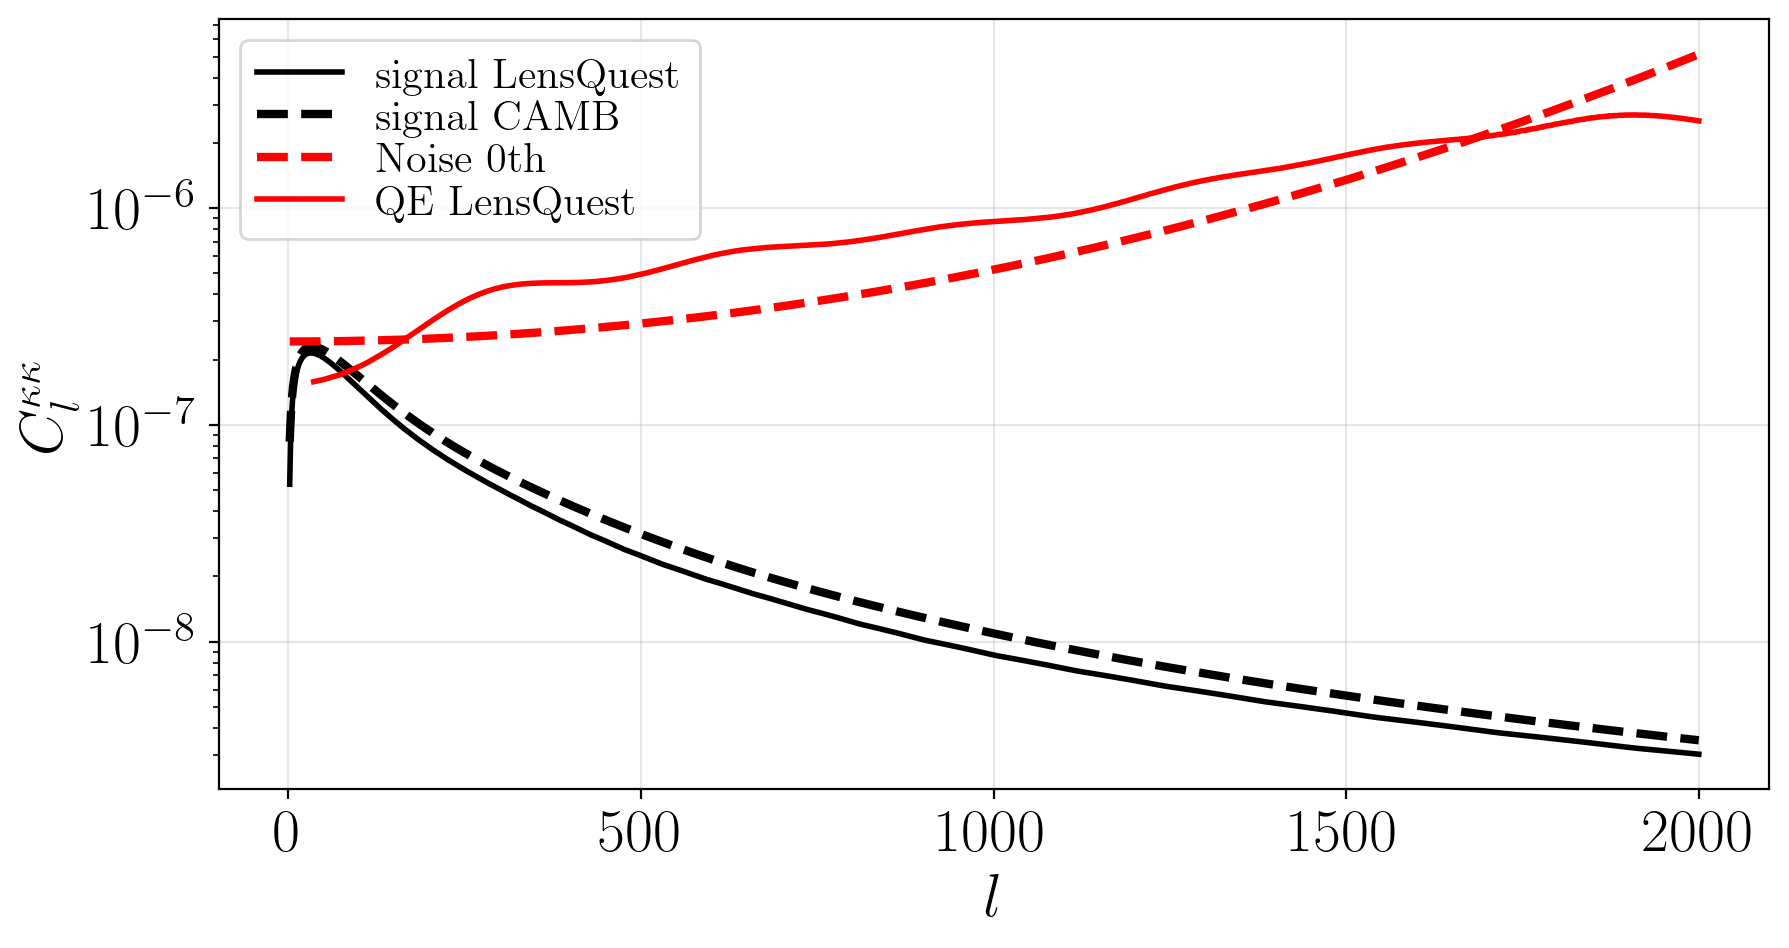

In [12]:
l_min=0
l_max=2000

Clkq, Nlkq = lensquest(l_min, l_max)
cambcl = CAMB_Cl(0.61,0.18,l_min, l_max)[0]
Nlk0n = Nlk0(l_min, l_max)

#Nlkq[np.isinf(Nlkq)] = 0

fig=plt.figure(0, figsize=(10, 5))
ax=fig.add_subplot(111)
#

ls=np.linspace(l_min,l_max,l_max+1 )

I = np.where( np.isfinite(Nlkq) == True)[0][0]

ax.plot(ls[2:], Clkq[2:], 'k-', lw=2, label=r'signal LensQuest')
ax.plot(ls[2:], cambcl[2:], 'k-', linestyle='--', lw=3, label=r'signal CAMB')
ax.plot(ls[2:], Nlk0n[2:], c ='r', linestyle='--', lw=3, label=r'Noise 0th')
ax.plot(ls[2:], Nlkq[2:], c ='r', lw=2, label=r'QE LensQuest')
ax.set_yscale('log')
#ax.set_xscale('log')
#ax.set_xlim(20,2000)
ax.legend(loc=2, fontsize='x-small', labelspacing=0.1)
ax.grid(True, alpha=0.3)
ax.set_xlabel(r'$l$')
ax.set_ylabel(r'$C_l^{\kappa \kappa}$')

/var/folders/_n/vm9nc6_54_1_2m60q4p1xhww0000gn/T/ipykernel_16003/1800645007.py:15: RuntimeWarning: invalid value encountered in divide
  snr_l_sq_th = (2*ls+1)*(cl_k_hi**2) / ((cl_k_hi**2) + (cl_k_k) * (cl_hihi))


computing the reconstruction noise
Doing full calculation: computeQuadEstPhiNormalizationFFT


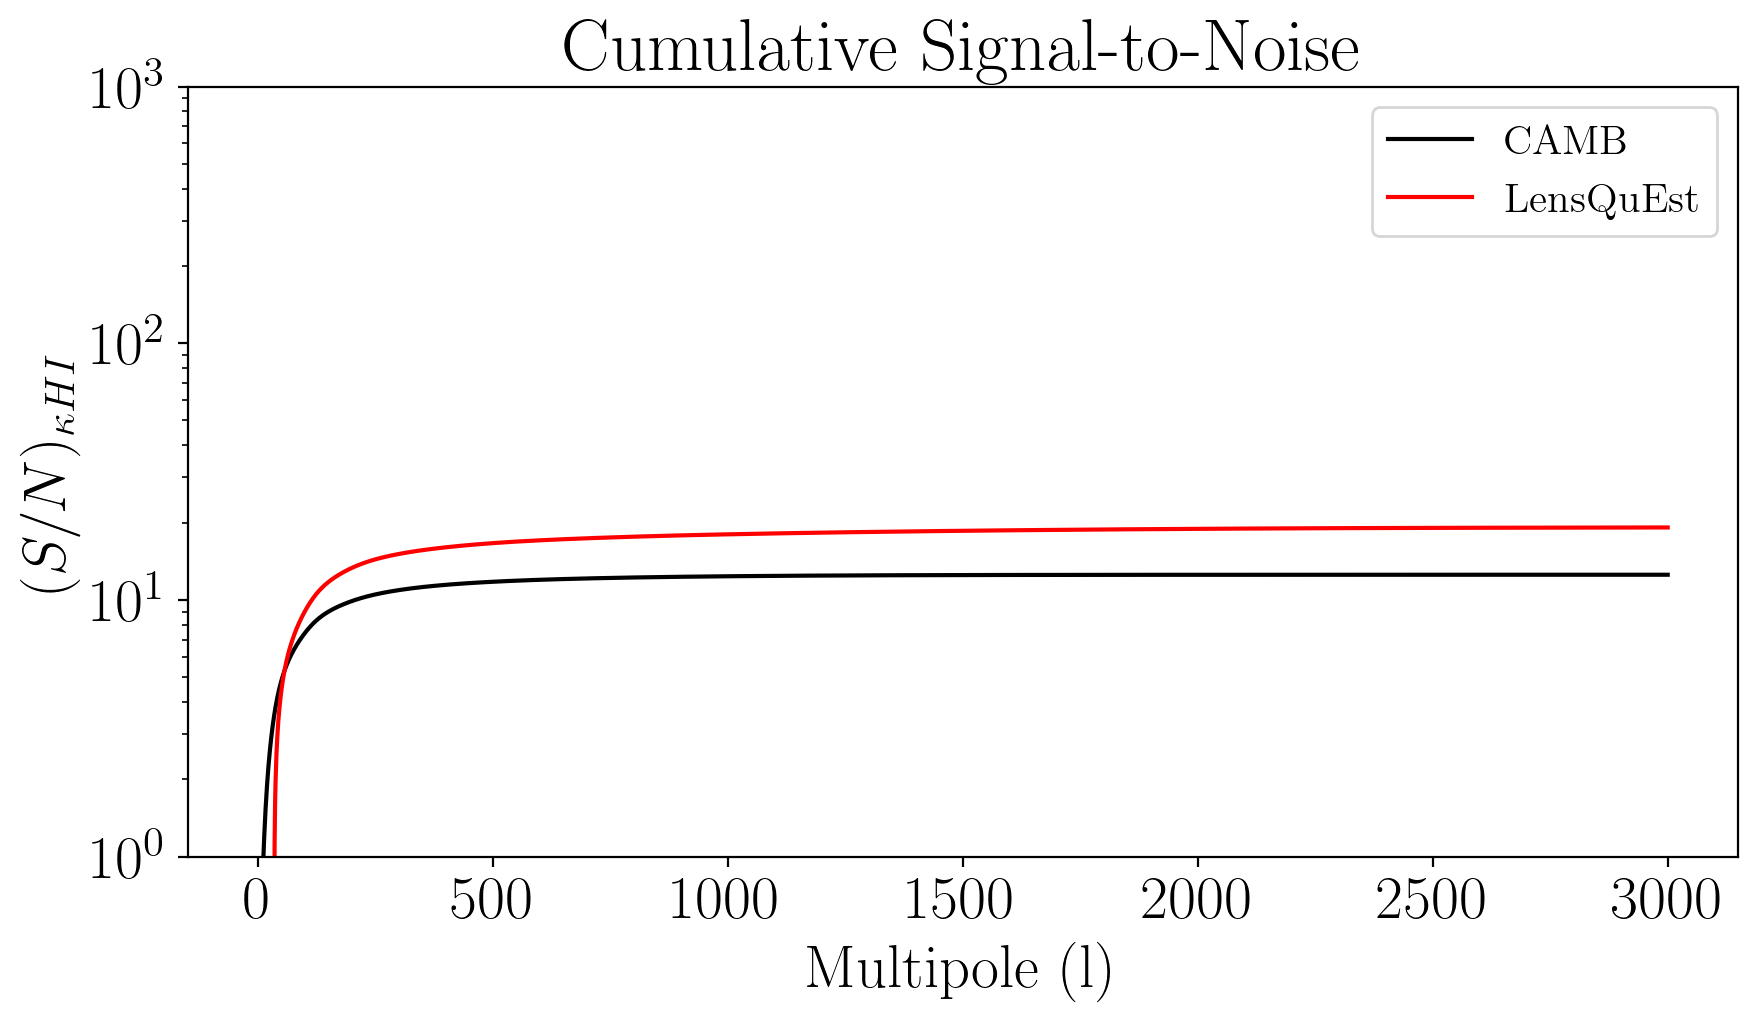

In [13]:
l_min=0
l_max=3000

fig, (ax3) = plt.subplots(1, 1, figsize=(10, 5), sharex=True)
ax3.set_yscale('log')
ax3.set_ylabel(r'$(S/N)_{\kappa HI}$')
ax3.set_xlabel('Multipole (l)')
ax3.set_title('Cumulative Signal-to-Noise')
#ax3.set_xlim(0, 2000)
ax3.set_ylim(1, 1000)


c_snr = SN(0.61, Delta_zs[1],l_min, l_max)[0]
c_snrq = SNq(0.61, Delta_zs[1],l_min, l_max)[0]

ls=np.linspace(l_min,l_max,l_max+1)

#c_snr_th = SN(Zi, Delta_zs[i],lmax)[1]
ax3.plot(ls[2:], c_snr[2:], label='CAMB', color='black')
ax3.plot(ls[2:], c_snrq[2:], label='LensQuEst', color='red', linestyle='-')
ax3.legend(fontsize=15)

computing the reconstruction noise
Doing full calculation: computeQuadEstPhiNormalizationFFT
computing the reconstruction noise
Doing full calculation: computeQuadEstPhiNormalizationFFT


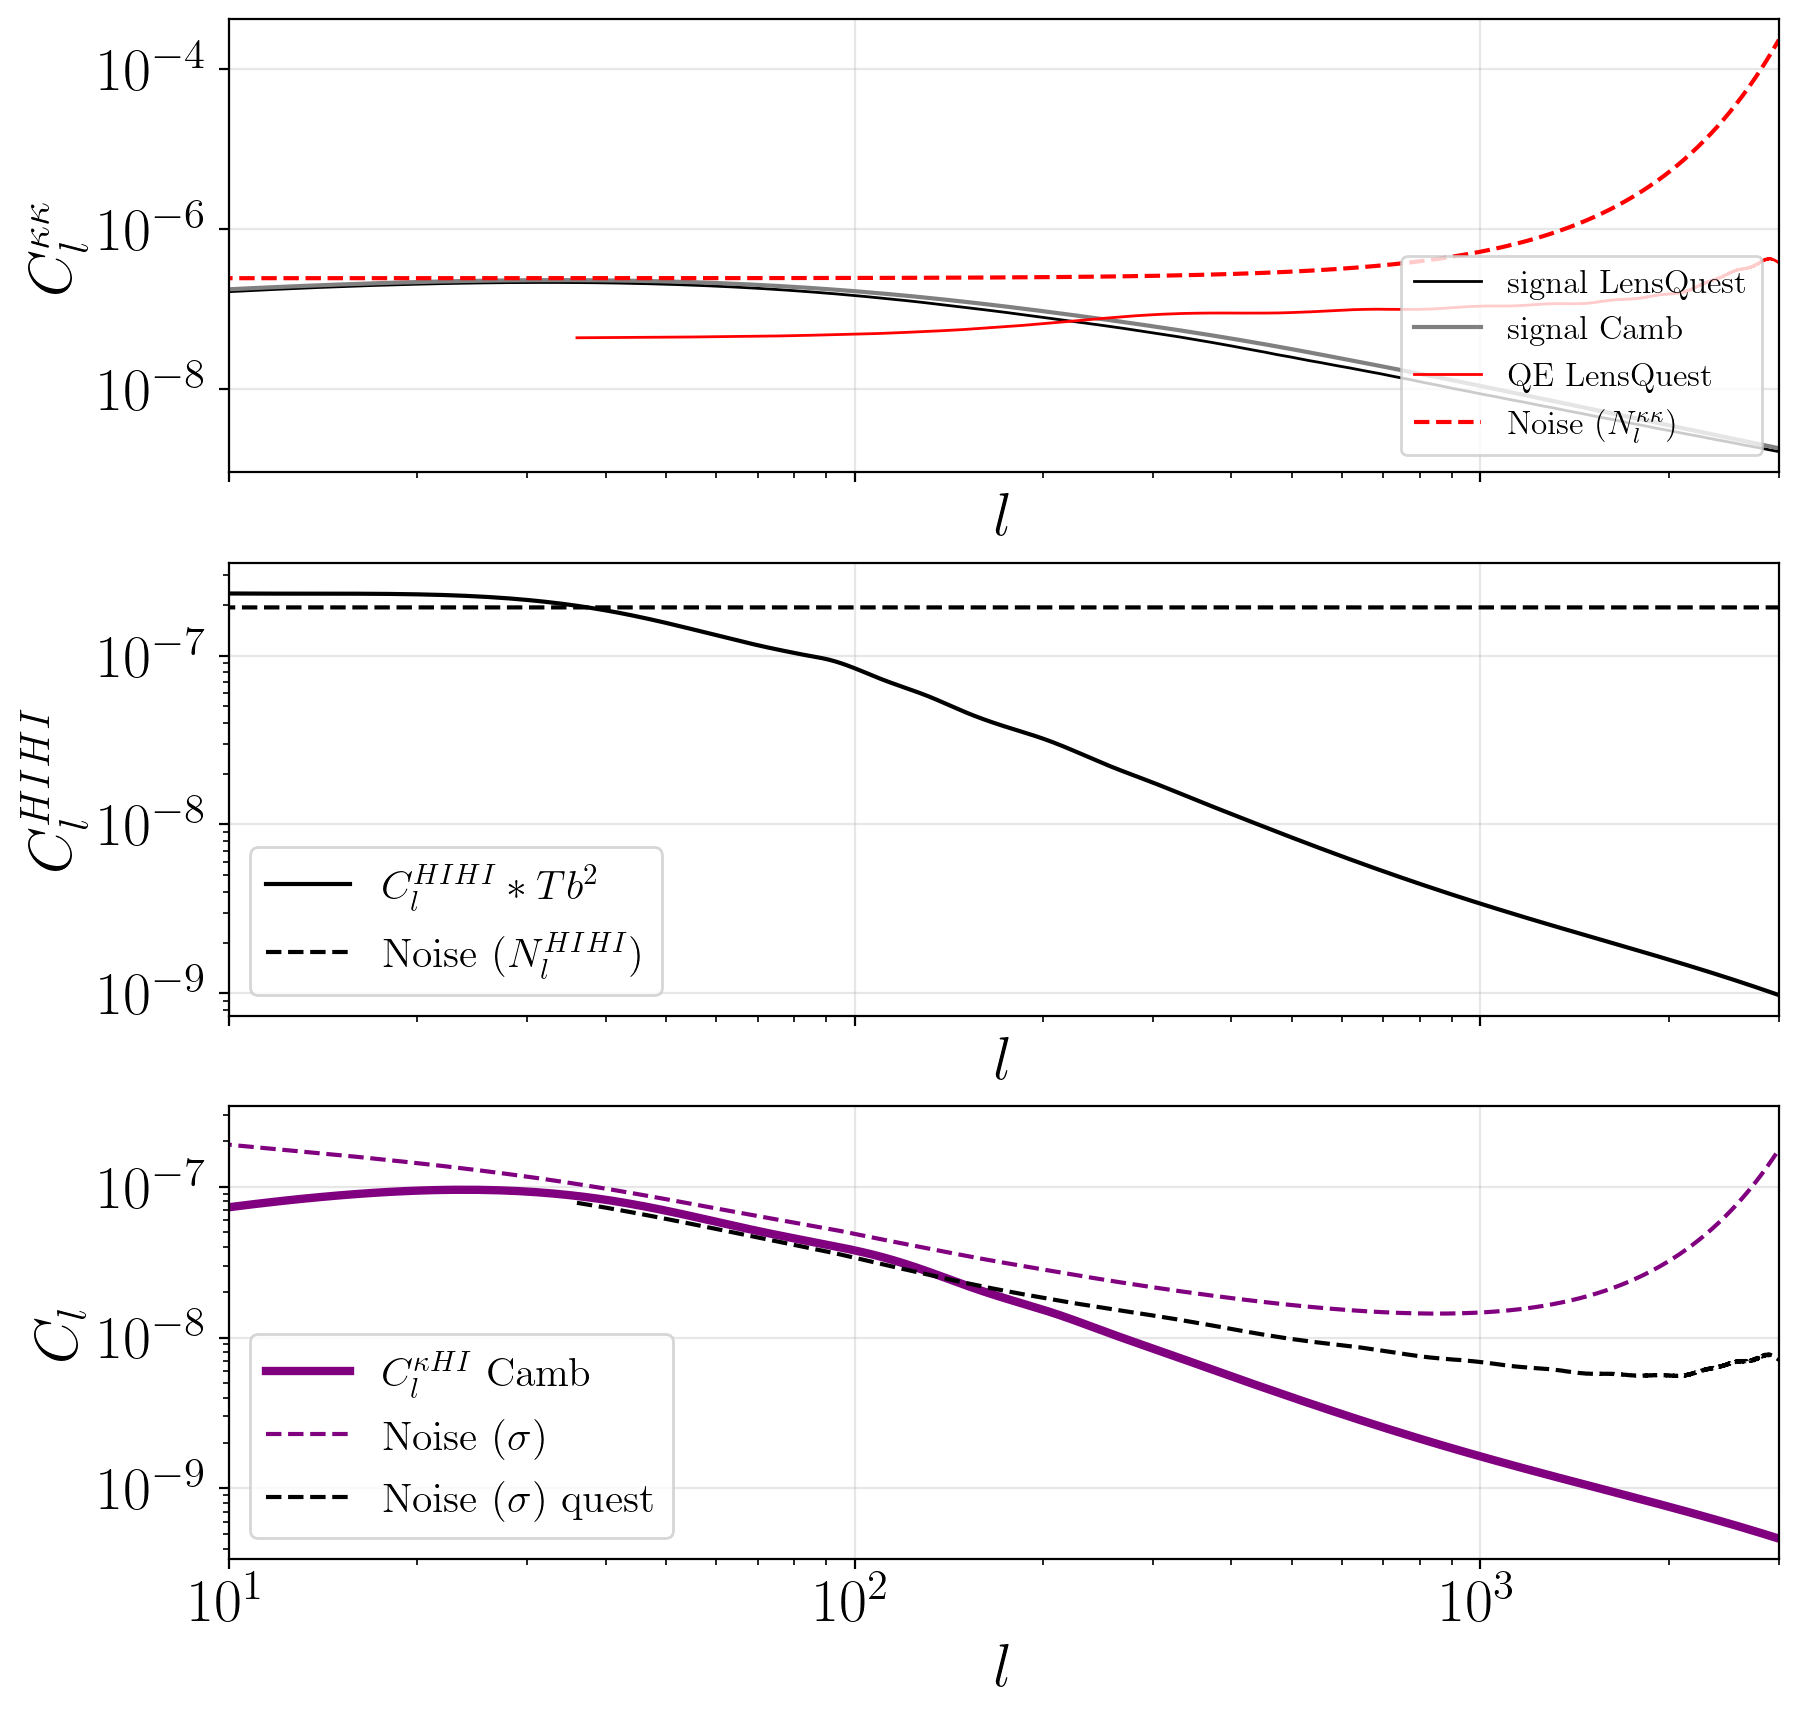

In [14]:
#plotting autos and cross power without noise
l_min=0
l_max=3000
Z = 0.61
DeltaZ = 0.18

cl_k_k, cl_hihi, cl_k_hi = CAMB_Cl(Z, DeltaZ, l_min, l_max)
N_kk, N_hihi, N_k_hi = noises_l(Z, DeltaZ, l_min, l_max)
Clkkq, Nlkkq = lensquest(l_min, l_max)

sigma_C_k_hiq = SNq(Z, DeltaZ, l_min, l_max)[1]


ls = np.linspace(l_min, l_max, l_max+1 )
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax1.loglog(ls[5:], Clkkq[5:], 'k-', lw=1, label=r'signal LensQuest')
ax1.loglog(ls[5:], cl_k_k[5:], 'gray', lw=1.5, label=r'signal Camb')

ax1.loglog(ls[5:], Nlkkq[5:], c='r', lw=1, label=r'QE LensQuest')
ax1.loglog(ls[5:], N_kk[5:], color='red', linestyle='--', label=r'Noise ($N_l^{\kappa \kappa}$) ')

ax1.set_ylabel(r'$C_l^{\kappa \kappa}$')
ax1.set_xlabel(r'$l$')

ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12, loc='lower right')
ax1.set_xlim(10,3000)
#
ax2.loglog(ls[2:], cl_hihi[2:], color='black', linestyle='-', label=r'$C_l^{HI HI} * Tb^2 $')
ax2.loglog(ls[2:], N_hihi[2:], color='black', linestyle='--', label=r'Noise ($N_l^{HI HI}$)')
ax2.set_yscale('log')
ax2.set_ylabel(r'$C_l^{HI HI}$')
ax2.set_xlabel(r'$l$')

ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=15)
ax2.set_xlim(10,3000)
#
ax3.loglog(ls[5:], cl_k_hi[5:], color='purple', lw=3, label=r'$C_l^{\kappa HI}$ Camb')
ax3.loglog(ls[5:], N_k_hi[5:], color='purple', linestyle='--', label=r' Noise ($\sigma$)')

#ax3.loglog(ls[5:], cl_k_hi[5:], color='black', label=r'$C_l^{\kappa HI}$ quest')
ax3.loglog(ls[5:], sigma_C_k_hiq[5:], color='black', linestyle='--', label=r' Noise ($\sigma$) quest')

#ax3.set_yscale('log')
ax3.set_ylabel(r'$C_l$')
ax3.set_xlabel(r'$l$')
ax3.set_xlim(10,3000)

ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=15)
